In [3]:
!pip install hopsworks[python] deltalake pandas requests -q
!pip install --upgrade protobuf -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
wandb 0.28.1 requires protobuf!=5.28.0,!=5.29.0,<8,>=5, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hopsworks 5.0.6 requires protobuf<5.0.0,>=4.25.4, but you have protobuf 7.36.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires p

In [4]:
from google.colab import userdata
import hopsworks
import pandas as pd

HOPSWORKS_API_KEY = userdata.get('HOPSWORKS_API_KEY')

print("Connecting to Hopsworks...")
project = hopsworks.login(api_key_value=HOPSWORKS_API_KEY, project="Aero_cast")
fs = project.get_feature_store()

print("Fetching feature group...")
feature_group = fs.get_feature_group(name="aqi_features", version=1)

print("Reading data...")
df = feature_group.read()

print(f"Total rows: {len(df)}")


Connecting to Hopsworks...

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42163
Fetching feature group...
Reading data...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (65.30s) 
Total rows: 17203


In [5]:
# Sort by actual time order first
df = df.sort_values("datetime").reset_index(drop=True)

# 3 days ahead = 72 hours ahead
HOURS_AHEAD = 3 * 24
df["aqi_target_3day"] = df["aqi"].shift(-HOURS_AHEAD)
df = df.dropna(subset=["aqi_target_3day"])

# Rolling average features to capture recent trend
df["aqi_rolling_24h"] = df["aqi"].rolling(window=24, min_periods=1).mean()
df["pm2_5_rolling_24h"] = df["pm2_5"].rolling(window=24, min_periods=1).mean()

print(f"Rows after processing: {len(df)}")
print(df[["datetime", "aqi", "aqi_target_3day", "aqi_rolling_24h"]].head())

Rows after processing: 17131
                   datetime  aqi  aqi_target_3day  aqi_rolling_24h
0 2024-08-14 13:00:00+00:00    4              4.0         4.000000
1 2024-08-14 14:00:00+00:00    4              4.0         4.000000
2 2024-08-14 15:00:00+00:00    5              4.0         4.333333
3 2024-08-14 16:00:00+00:00    5              5.0         4.500000
4 2024-08-14 17:00:00+00:00    5              5.0         4.600000


In [6]:
feature_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3",
                 "hour", "day", "month", "aqi_change_rate",
                 "aqi_rolling_24h", "pm2_5_rolling_24h"]
target_col = "aqi_target_3day"

split_index = int(len(df) * 0.85)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows")

Training set: 14561 rows
Test set: 2570 rows


In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = {}

print("Training Ridge Regression...")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
results["Ridge Regression"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, ridge_preds)),
    "MAE": mean_absolute_error(y_test, ridge_preds),
    "R2": r2_score(y_test, ridge_preds)
}

print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
results["Random Forest"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
    "MAE": mean_absolute_error(y_test, rf_preds),
    "R2": r2_score(y_test, rf_preds)
}

print("\nResults:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

Training Ridge Regression...
Training Random Forest...

Results:

Ridge Regression:
  RMSE: 0.7275
  MAE: 0.5861
  R2: 0.0280

Random Forest:
  RMSE: 0.7591
  MAE: 0.6282
  R2: -0.0585


In [8]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Neural networks need scaled inputs to train properly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Building TensorFlow model...")
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

tf_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training TensorFlow model...")
history = tf_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    verbose=1
)

tf_preds = tf_model.predict(X_test_scaled).flatten()

results["TensorFlow Neural Network"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, tf_preds)),
    "MAE": mean_absolute_error(y_test, tf_preds),
    "R2": r2_score(y_test, tf_preds)
}

print("\nAll results so far:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

Building TensorFlow model...
Training TensorFlow model...


Epoch 1/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.2730 - mae: 1.0349 - val_loss: 1.8039 - val_mae: 1.2157
Epoch 2/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5710 - mae: 0.5868 - val_loss: 1.0500 - val_mae: 0.8811
Epoch 3/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4960 - mae: 0.5424 - val_loss: 0.9449 - val_mae: 0.8256
Epoch 4/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4648 - mae: 0.5224 - val_loss: 1.1340 - val_mae: 0.9188
Epoch 5/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4459 - mae: 0.5095 - val_loss: 1.0053 - val_mae: 0.8603
Epoch 6/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4340 - mae: 0.5025 - val_loss: 0.6213 - val_mae: 0.6283
Epoch 7/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4201 - mae: 0.4945 - val_loss: 0.7251 - val_mae: 0.6953
Epoch 8/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4097 - mae: 0.4860 - val_loss: 0.7562 - val_mae: 0.7163
Epoch 9/30
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [9]:
import joblib

# Save the trained model to a local file first
joblib.dump(ridge_model, "ridge_model.pkl")

print("Connecting to Model Registry...")
mr = project.get_model_registry()

# Register the model with its performance metrics attached
model = mr.python.create_model(
    name="aqi_ridge_model",
    metrics={
        "rmse": results["Ridge Regression"]["RMSE"],
        "mae": results["Ridge Regression"]["MAE"],
        "r2": results["Ridge Regression"]["R2"]
    },
    description="Ridge Regression model predicting AQI 3 days ahead for Rawalpindi. Best of 3 models compared (Ridge, Random Forest, TensorFlow)."
)

print("Uploading model...")
model.save("ridge_model.pkl")
print("Model saved to registry!")

Connecting to Model Registry...
Uploading model...


  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'ridge_model.pkl' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/ridge_model.pkl: 0.000%|          | 0/1057 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/42163/models/aqi_ridge_model/13
Model saved to registry!


In [10]:
!pip install shap -q

Creating SHAP explainer...
Generating summary plot...


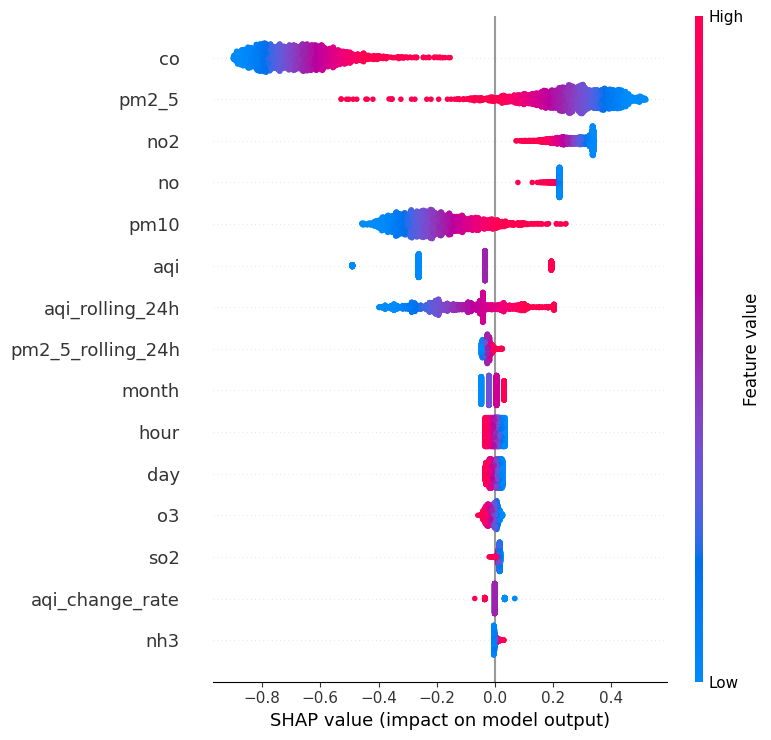

In [11]:
import shap
import matplotlib.pyplot as plt

print("Creating SHAP explainer...")
explainer = shap.LinearExplainer(ridge_model, X_train)
shap_values = explainer(X_test)

print("Generating summary plot...")
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.savefig("shap_summary.png", bbox_inches="tight", dpi=150)
plt.show()

In [12]:
   from google.colab import files
   files.download("shap_summary.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>